In [22]:
import torch
import torchvision
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
from PIL import Image

In [23]:
import os
os.chdir("C:/Users/gargp/OneDrive/Desktop/DIV2K-SRGAN")

In [24]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Conv2d(3,64,3,1,1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,1,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,64,4,2,1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,1,1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,1,1),
            nn.ReLU(),
            nn.Conv2d(64,3,3,1,1)
        )
    def forward(self,x,use_tanh=False):
        out = self.gen(x)
        if use_tanh:
            out = torch.tanh(out)
        return out

In [25]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.dis = nn.Sequential(
            nn.Conv2d(3,64,3,2,1),
            nn.LeakyReLU(.2),
            nn.Conv2d(64,128,3,2,1),
            nn.LeakyReLU(.2),
            nn.Conv2d(128,256,3,2,1),
            nn.LeakyReLU(.2),
            nn.Conv2d(256,1,3,1,1),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
    def forward(self,x):
        return self.dis(x)
     

In [26]:
lr = 2e-4
batch_size = 6
loss = nn.BCEWithLogitsLoss()
betas = (.9,.999)
lamb = 1e-4
epochs = 75

In [27]:
disc = Discriminator()
gen = Generator()
disc_optim = optim.Adam(disc.parameters(),betas=betas,lr=lr)
gen_optim = optim.Adam(gen.parameters(),betas=betas,lr=lr)


In [ ]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5]*3,std=[0.5]*3) 
])
dataset = ImageFolder(
    root="Data",
    transform= transform
)
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)


In [29]:
real_img, _ = next(iter(loader))
print(real_img.min(), real_img.max(), real_img.mean())


tensor(-1.) tensor(0.9686) tensor(-0.1616)


In [30]:
for epoch in range(epochs):
    for real_img, _ in loader:
        if epoch<50:
            real_64 = (real_img+1)/2
            real_32 = (F.resize(real_64,[32,32]))
            fake = gen(real_32)
            loss_g = torch.mean(torch.abs(real_64-fake))
            gen_optim.zero_grad()
            loss_g.backward()
            gen_optim.step()
        else:
            real_64 = real_img
            real_32 = F.resize(real_64,[32,32])
            fake = gen(real_32,use_tanh=True)
            disc_real = disc(real_64).view(-1)
            disc_fake = disc(fake.detach()).view(-1)
            disc_loss_real = loss(disc_real,torch.ones_like(disc_real))
            disc_loss_fake = loss(disc_fake,torch.zeros_like(disc_fake))
            loss_d = disc_loss_fake+disc_loss_real

            disc_optim.zero_grad()
            loss_d.backward()
            disc_optim.step()


            output = disc(fake)
            l1_loss = torch.mean(torch.abs(real_64-fake))
            loss_g = l1_loss + lamb*loss(output,torch.ones_like(output))
            gen_optim.zero_grad()
            loss_g.backward()
            gen_optim.step()


In [31]:
def show_image(tensor):
    img = (tensor+1)/2
    img = img.squeeze(0)
    img = img.permute(1,2,0)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [32]:
image = Image.open("Data/test_images/0801.png").convert("RGB")
image = F.resize(image,[32,32])
image = F.to_tensor(image)
image = F.normalize(image,[0.5]*3,[0.5]*3)
image = image.unsqueeze(0)

REAL: -0.9921568632125854 1.0 0.05712254345417023
FAKE: -0.9846348762512207 0.9905743598937988 0.05450021103024483


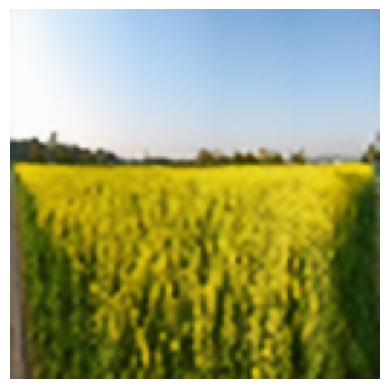

In [ ]:
gen.eval()

real_img, _ = next(iter(loader))  
real_img = real_img[:1]            

with torch.no_grad():
    fake = gen(real_img, use_tanh=True)

print("REAL:", real_img.min().item(), real_img.max().item(), real_img.mean().item())
print("FAKE:", fake.min().item(), fake.max().item(), fake.mean().item())

show_image(fake)


In [34]:
print(image.max(),image.min())

tensor(0.8667) tensor(-0.8353)


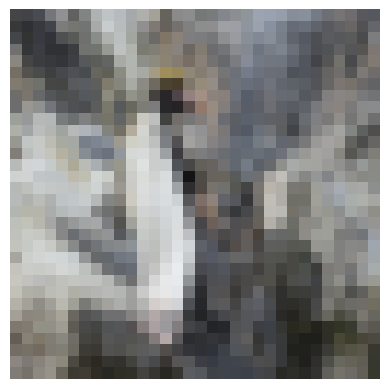

In [35]:
show_image(image)

In [36]:
gen.eval()
with torch.no_grad():
    fake = gen(image,use_tanh=True)


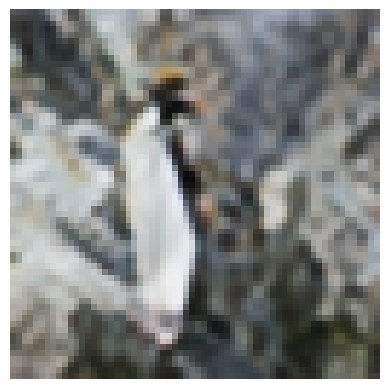

In [37]:
show_image(fake)

In [38]:
image = Image.open("Data/test_images/0809.png").convert("RGB")
image = F.resize(image,[32,32])
image = F.to_tensor(image)
image = F.normalize(image,[0.5]*3,[0.5]*3)


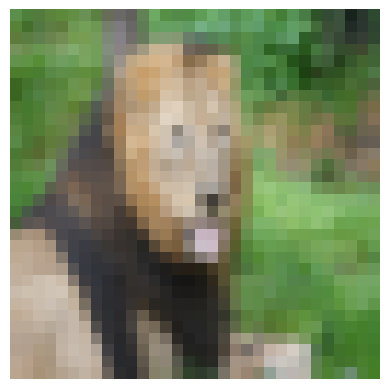

In [45]:
show_image(image)

In [40]:
gen.eval()
with torch.no_grad():
    fake = gen(image,use_tanh=True)

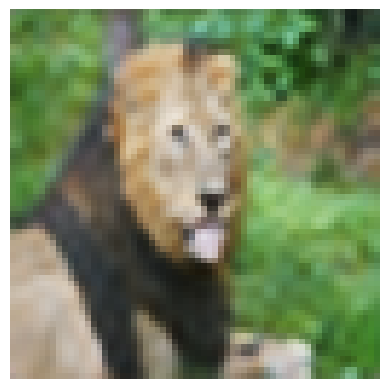

In [41]:
show_image(fake)